In [1]:
from sklearn.neighbors import KNeighborsClassifier

Create the model with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)

Train the model
knn.fit(X_train, y_train)

Make predictions
predictions = knn.predict(X_test)

SyntaxError: invalid syntax (5561651.py, line 3)

In [8]:
# KNN Demo on Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict and evaluate
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

# Display results
print("Predictions:", predictions)
print("Accuracy:", accuracy)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
Accuracy: 1.0


In [4]:
import numpy as np
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [5]:
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

In [6]:
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

In [7]:
prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

A


In [10]:
# KNN Grid Search Demo with Synthetic Dataset
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Step 1: Create a synthetic classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,  # ✅ Increased to satisfy cluster constraint
    n_classes=3,
    random_state=42
)

# Step 2: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Define hyperparameter grid
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Step 4: Initialize model and run grid search
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)
grid_search.fit(X_train, y_train)

# Step 5: Display results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

# Step 6: Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test set accuracy: {test_accuracy:.3f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Best cross-validation score: 0.786
Test set accuracy: 0.835


Dataset shape: (70000, 784)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


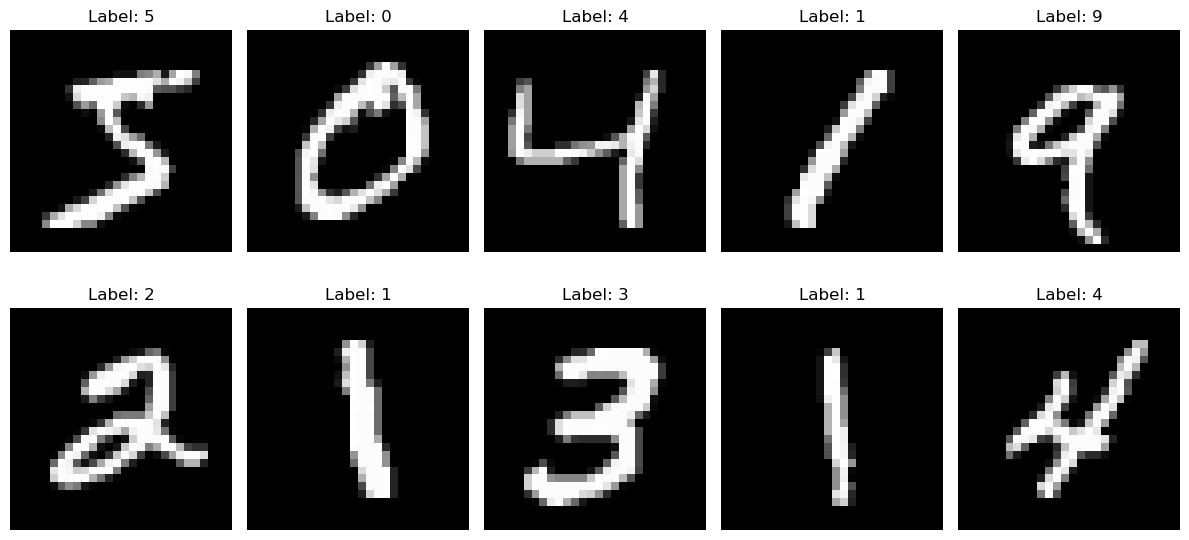

In [11]:
# Step 1: Import libraries
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

# Step 3: Show dataset info
print(f"Dataset shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

# Step 4: Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row, col = divmod(i, 5)
    axes[row, col].imshow(X.iloc[i].values.reshape(28, 28), cmap='gray')
    axes[row, col].set_title(f"Label: {y.iloc[i]}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# This code trains a K-Nearest Neighbors (KNN) model to recognize handwritten digits from the MNIST dataset. 

# Step 1: Import libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 2: Preprocessing
print("Preprocessing data...")
X = X / 255.0  # Normalize pixel values to range [0, 1]

# Step 3: Split into training and test sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Step 4: Use smaller subset for faster demo
X_train_sample = X_train[:10000]
y_train_sample = y_train[:10000]
X_test_sample = X_test[:2000]
y_test_sample = y_test[:2000]

# Step 5: Train KNN classifier
print("Training KNN classifier...")
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_sample, y_train_sample)

# Step 6: Make predictions
print("Making predictions...")
y_pred = knn.predict(X_test_sample)

# Step 7: Evaluate model
accuracy = (y_pred == y_test_sample).mean()
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test_sample, y_pred))

Preprocessing data...
Training KNN classifier...
Making predictions...
Accuracy: 0.923

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       175
           1       0.90      1.00      0.95       234
           2       0.98      0.89      0.93       219
           3       0.91      0.91      0.91       207
           4       0.94      0.94      0.94       217
           5       0.91      0.91      0.91       179
           6       0.95      0.97      0.96       178
           7       0.89      0.91      0.90       205
           8       0.95      0.80      0.87       192
           9       0.89      0.90      0.89       194

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



Dataset Info:
        CustomerID          Age  Annual_Income  Spending_Score
count  2000.000000  2000.000000    2000.000000      2000.00000
mean   1000.500000    43.805500   81687.716000        50.50800
std     577.494589    14.929203   38806.602132        28.36821
min       1.000000    18.000000   15138.000000         1.00000
25%     500.750000    31.000000   47352.750000        26.00000
50%    1000.500000    44.000000   81792.000000        51.00000
75%    1500.250000    56.000000  114244.000000        75.00000
max    2000.000000    69.000000  149837.000000        99.00000

Class distribution:
Value_Segment
Low       1018
Medium     579
High       403
Name: count, dtype: int64
Best parameters: {'n_neighbors': 7, 'weights': 'distance'}

Model Performance:
Accuracy: 0.968
Classification Report:
              precision    recall  f1-score   support

        High       0.99      0.96      0.97        80
         Low       0.99      0.97      0.98       204
      Medium       0.93      0.9

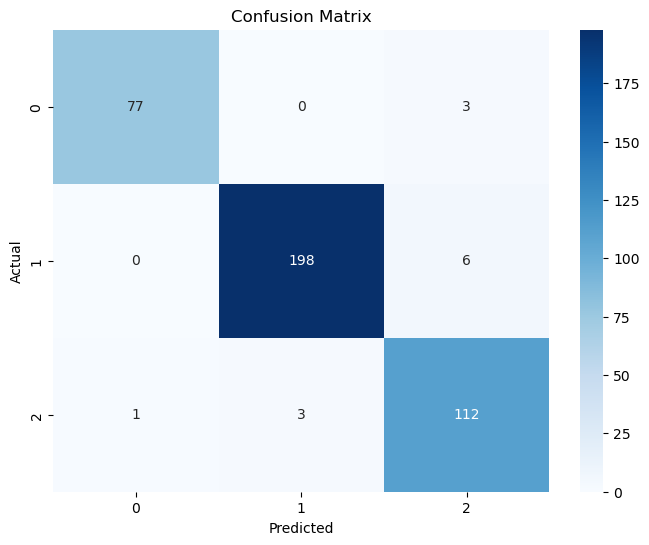

In [17]:
# We want to build a machine learning model that can predict a customer’s Value Segment (Low, Medium, High) 
# based on their Age, Annual Income, and Spending Score. We’re using the K-Nearest Neighbors (KNN) algorithm 
# and tuning it to find the best settings.

# Step 1: Import libraries
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load data
df = pd.read_csv('customer_segmentation.csv')

# Step 3: Exploratory Data Analysis
print("Dataset Info:")
print(df.describe())
print(f"\nClass distribution:\n{df['Value_Segment'].value_counts()}")

# Step 4: Feature preparation
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]
y = df['Value_Segment']

# Step 5: Scaling (crucial for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Step 7: Grid search for optimal parameters
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Step 8: Best model
best_knn = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Step 9: Predictions
y_pred = best_knn.predict(X_test)
accuracy = (y_pred == y_test).mean()
print("\nModel Performance:")
print(f"Accuracy: {accuracy:.3f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
